In [1]:
# import libraries
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from captum.attr import IntegratedGradients
import matplotlib.pyplot as plt
import sys
from os import path
from tqdm import tqdm

c:\Users\nnitzan\miniconda3\envs\pytorch_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# device configuration
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [7]:
# define path to data
PATH = r'C:\Users\nnitzan\Desktop\spikes2lfp\session_1044594870'

In [10]:
# import data
lfp      = np.load(PATH + '_lfp.npy').astype(np.float32)
X        = np.load(PATH + '_spikes.npy').astype(np.float32)
df       = pd.read_csv(PATH + '_info.csv')
print(lfp.shape)
print(X.shape)
print(df.head())

(901200, 1)
(901200, 748)
  location   probe  firing_rate
0      POL  probeB    12.605778
1      CA1  probeB     3.409879
2    VISpm  probeB     0.731049
3       DG  probeB     0.228691
4      POL  probeB     1.995846


In [11]:
# define constants
input_size  = X.shape[1]
hidden_size = 10  # number of units in the hidden state
num_layers  = 1  # number of vertical stacks of hidden layers (note: only the final layer gives an output)
batchsize   = 1
seqlength   = 125
bin_size    = 0.004

In [12]:
# Preprocess data
num_trials = int(lfp.shape[0] / seqlength)
X = X[:num_trials * seqlength, :]
lfp = lfp[:num_trials * seqlength, :]
X_reshaped = np.reshape(X, (num_trials, seqlength, X.shape[1]))
lfp_reshaped = np.reshape(lfp, (num_trials, seqlength))
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, lfp_reshaped, test_size=0.2, random_state=42)
X_train = X_train.reshape(X_train.shape[0] * X_train.shape[1], X_train.shape[2])
X_test = X_test.reshape(X_test.shape[0] * X_test.shape[1], X_test.shape[2])
y_train = y_train.reshape(y_train.shape[0] * y_train.shape[1], 1)
y_test = y_test.reshape(y_test.shape[0] * y_test.shape[1], 1)
X_trainT = torch.tensor(X_train).float()
y_trainT = torch.tensor(y_train).float()
X_testT = torch.tensor(X_test).float()
y_testT = torch.tensor(y_test).float()

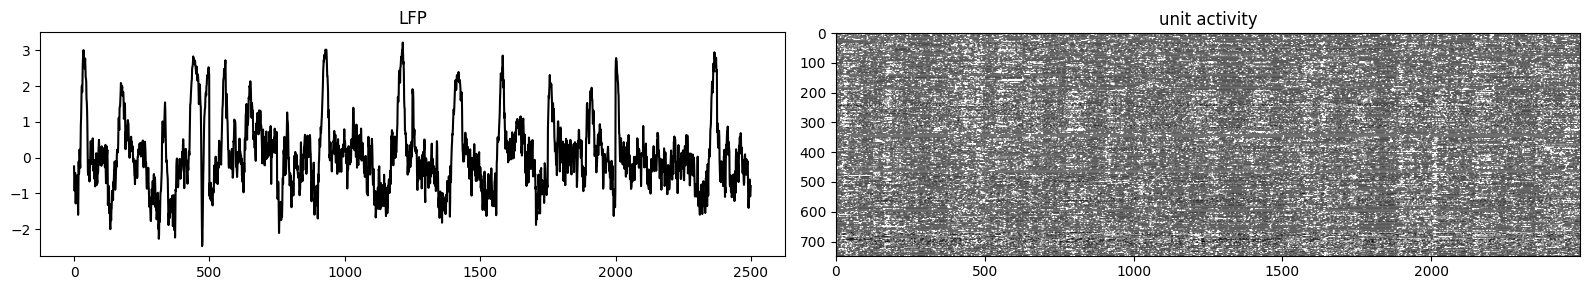

In [95]:
fig, ax = plt.subplots(1,2,figsize=(16, 3))

ax[0].plot(y_train[:int(10/bin_size)],'k',label='LFP')
ax[0].set_title('LFP')

ax[1].imshow(X_train[:int(10/bin_size),:].T, vmin=-1, vmax=1, cmap='gray')
ax[1].set_title('unit activity')

plt.tight_layout()
plt.show()

## create the model

In [14]:
# Define LSTM model
class LSTMnet(nn.Module):
    def __init__(self, input_size, num_hidden, num_layers, print=False):
        super().__init__()
        self.print = print
        self.input_size = input_size
        self.num_hidden = num_hidden
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, num_hidden, num_layers, dropout=0.5)
        self.out = nn.Linear(num_hidden, 1)

    def forward(self, x):
        if self.print:
            print(f'Input: {list(x.shape)}')
        y, hidden = self.lstm(x)
        if self.print:
            print(f'RNN-out: {list(y.shape)}')
            print(f'RNN-hidden: {list(hidden[0].shape)}')
            print(f'RNN-cell: {list(hidden[1].shape)}')
        o = self.out(y)
        if self.print:
            print(f'Output: {list(o.shape)}')
        return o

In [35]:
class TransformerModel(nn.Module):
    def __init__(self, input_size, num_heads, num_layers, hidden_dim, output_size):
        super(TransformerModel, self).__init__()
        self.embedding = nn.Linear(input_size, hidden_dim)
        self.pos_encoder = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads)
        self.transformer = nn.TransformerEncoder(self.pos_encoder, num_layers=num_layers)
        self.fc = nn.Linear(hidden_dim, output_size)

    def forward(self, src):
        src = self.embedding(src)
        src = self.transformer(src)
        output = self.fc(src)
        return output

In [84]:
class TransformerModelED(nn.Module):
    def __init__(self, input_size, hidden_dim, num_heads, num_layers, output_size):
        super(TransformerModelED, self).__init__()
        self.encoder_embedding = nn.Linear(input_size, hidden_dim)
        self.decoder_embedding = nn.Linear(output_size, hidden_dim)
        self.transformer = nn.Transformer(
            d_model=hidden_dim,
            nhead=num_heads,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers
        )
        self.fc_out = nn.Linear(hidden_dim, output_size)

    def forward(self, src, tgt):
        src = self.encoder_embedding(src)
        tgt = self.decoder_embedding(tgt)
        # print(f"src shape after embedding: {src.shape}")
        # print(f"tgt shape after embedding: {tgt.shape}")
        src = src.permute(1, 0, 2)  # Transformer expects (seq_len, batch_size, embed_dim)
        tgt = tgt.permute(1, 0, 2)  # Transformer expects (seq_len, batch_size, embed_dim)
        # print(f"src shape after permute: {src.shape}")
        # print(f"tgt shape after permute: {tgt.shape}")
        output = self.transformer(src, tgt)
        output = self.fc_out(output)
        output = output.permute(1, 0, 2)  # Permute back to (batch_size, seq_len, output_size)
        return output

In [81]:
input_size = 748
output_size = 1
num_heads = 8
num_layers = 6
hidden_dim = 512 # Assuming target sequence has the same feature dimension as the input sequence

# model = TransformerModel(input_size, num_heads, num_layers, hidden_dim, output_size)
model = TransformerModelED(input_size, hidden_dim, num_heads, num_layers, output_size)
# test the model with some data
# somedata = X_trainT[:seqlength,:].view(seqlength,1,input_size)
X_train_seq = X_trainT[:seqlength, :].view(seqlength, 1, input_size) # Adjust input dimensions
y_train_seq = y_trainT[:seqlength].view(seqlength, 1, output_size)

# print(X_train_seq.shape)
# print(y_train_seq.shape)

y  = model(X_train_seq, y_train_seq)
# print(y.shape)
lossfun = nn.MSELoss()
lossfun(torch.squeeze(y), torch.squeeze(y_trainT[:seqlength]))

src shape after embedding: torch.Size([125, 1, 512])
tgt shape after embedding: torch.Size([125, 1, 512])
src shape after permute: torch.Size([1, 125, 512])
tgt shape after permute: torch.Size([1, 125, 512])


tensor(1.5360, grad_fn=<MseLossBackward0>)

In [15]:
# create an LSTM instance
net = LSTMnet(input_size,hidden_size,num_layers, print = True)

# test the model with some data
somedata = X_trainT[:seqlength,:].view(seqlength,1,input_size)

y  = net(somedata)

lossfun = nn.MSELoss()
lossfun(torch.squeeze(y), torch.squeeze(y_trainT[:seqlength]))

c:\Users\nnitzan\miniconda3\envs\pytorch_env\lib\site-packages\torch\nn\modules\rnn.py:65: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  "num_layers={}".format(dropout, num_layers))


Input: [125, 1, 748]
RNN-out: [125, 1, 10]
RNN-hidden: [1, 1, 10]
RNN-cell: [1, 1, 10]
Output: [125, 1, 1]


tensor(1.0785, grad_fn=<MseLossBackward0>)

## a function to train the model 

In [82]:
def train(model_inp, numepochs = 50):
    lossfun = nn.MSELoss()
    N = y_train.shape[0]
    model_inp.to(device)
    optimizer = torch.optim.Adam(model_inp.parameters(),lr=.001, weight_decay=0.001)
    # initialize losses
    losses = np.zeros(numepochs)

    for epochi in range(numepochs):
      # loop over data segments
      seglosses = []
    
      for timei in range(0, N - seqlength, seqlength):
        # grab a snippet of data
        # X = X_trainT[timei:timei+seqlength,:].view(seqlength,1,input_size).to(device)
        # y = y_trainT[timei:timei+seqlength].view(seqlength,1).to(device)
        X = X_trainT[:seqlength, :].view(seqlength, 1, input_size).to(device) # Adjust input dimensions
        y = y_trainT[:seqlength].view(seqlength, 1, output_size).to(device)    
        # forward pass and loss
        # yHat = model_inp(X)
        yHat = model_inp(X,y)
        loss = lossfun(torch.squeeze(y), torch.squeeze(yHat))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        seglosses.append(loss.item())
      # average losses from this epoch
      losses[epochi] = np.mean(seglosses)
      msg = f'Finished epoch {epochi+1}/{numepochs}'
      sys.stdout.write('\r' + msg)
    return losses

In [85]:
# model = TransformerModel(input_size, num_heads, num_layers, hidden_dim, output_size)
model2 = TransformerModelED(input_size, hidden_dim, num_heads, num_layers, output_size)

losses2 = train(model2, numepochs=10)

Finished epoch 10/10

In [86]:
TRANSFORMER_PATH = PATH + '_trained_transformer2.pt'
torch.save(model2.state_dict(), TRANSFORMER_PATH)

In [19]:
def train_load_save_model(model_obj, model_path):
    if path.isfile(model_path):
        # load model
        print('Loading pre-trained model from: {}'.format(model_path))
        model_obj.load_state_dict(torch.load(model_path, weights_only=True))
        losses = None
        return losses
    else:    
        # train model
        losses = train(model_obj)
        print('Finished training the model. Saving the model to the path: {}'.format(model_path))
        torch.save(model_obj.state_dict(), model_path)
        return losses

In [20]:
model = LSTMnet(input_size,hidden_size,num_layers)

SAVED_MODEL_PATH = PATH + '_trained_lstm.pt'
losses = train_load_save_model(model, SAVED_MODEL_PATH)
model = model.to(device)

c:\Users\nnitzan\miniconda3\envs\pytorch_env\lib\site-packages\torch\nn\modules\rnn.py:65: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  "num_layers={}".format(dropout, num_layers))


Finished epoch 50/50Finished training the model. Saving the model to the path: C:\Users\nnitzan\Desktop\spikes2lfp\session_1044594870_trained_lstm.pt


Text(0.5, 1.0, 'Model loss')

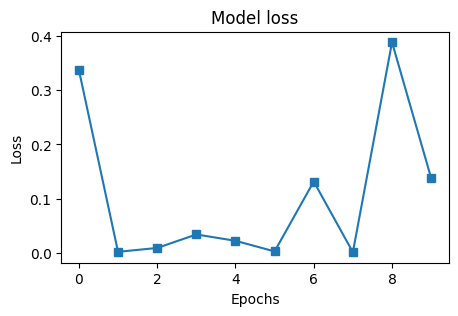

In [87]:
fig,ax = plt.subplots(1,1,figsize=(5,3))

ax.plot(losses2,'s-')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.set_title('Model loss')


In [42]:
# Function to evaluate the model
def evaluate(model, X_data, y_data):
    model.eval()
    y_hat = np.zeros(y_data.shape[0])
    with torch.no_grad():
        for timei in range(0, y_data.shape[0] - seqlength, seqlength):
            X = X_data[timei:timei+seqlength, :].view(seqlength, 1, input_size).to(device)
            yy = model(X)
            y_hat[timei:timei+seqlength] = np.squeeze(yy.cpu().numpy())
    return y_hat

## test the network

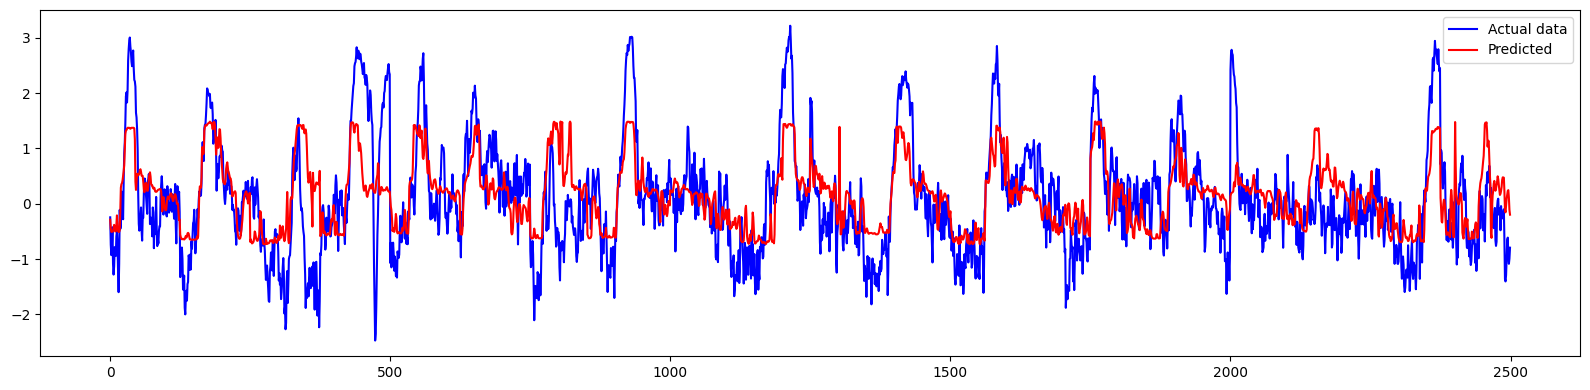

In [43]:
y_hat_train = evaluate(model, X_trainT, y_trainT)

## plot!
fig,ax = plt.subplots(1,1,figsize=(16,4))
ax.plot(y_train[:int(10/bin_size)],'b',label='Actual data')
# ax.plot(power_train[:int(10/bin_size),4],'b',label='Actual data')

ax.plot(y_hat_train[:int(10/bin_size)],'r',label='Predicted')
ax.legend()

plt.tight_layout()
plt.show()


## Test on new data

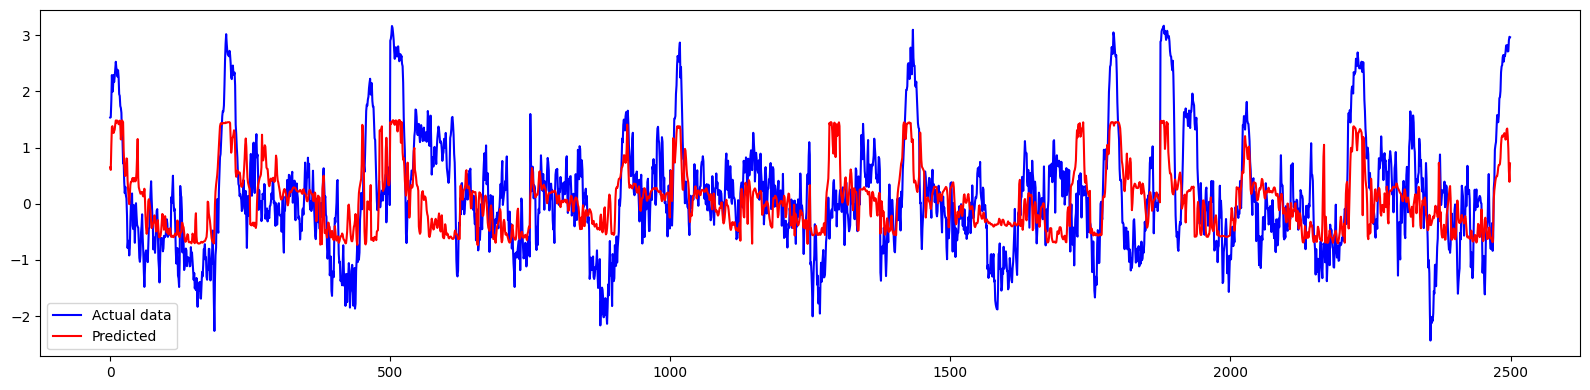

In [44]:
y_hat_test = evaluate(model, X_testT, y_testT)

## plot!
fig,ax = plt.subplots(1,1,figsize=(16,4))
ax.plot(y_test[:int(10/bin_size)],'b',label='Actual data')
# ax.plot(power_test[:int(10/bin_size),4],'b',label='Actual data')
ax.plot(y_hat_test[:int(10/bin_size)],'r',label='Predicted')
ax.legend()

plt.tight_layout()
plt.show()

In [45]:
# print mse for test data 
print(f'MSE test data: {lossfun(torch.squeeze(y_testT), torch.squeeze(torch.tensor(y_hat_test)))}')

MSE test data: 0.698110872750445


## test on spontaneous data

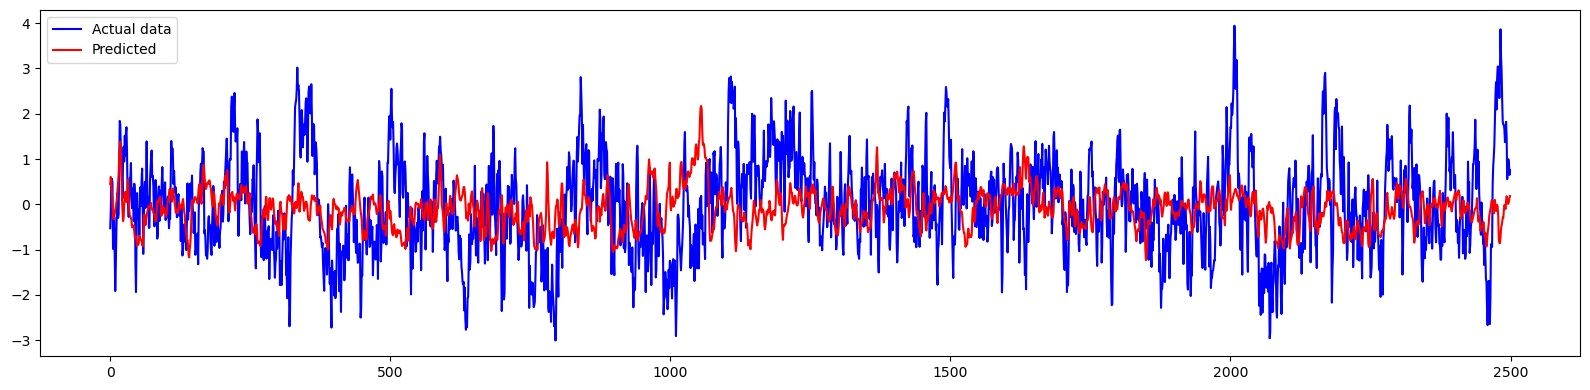

In [96]:
X_spont    = np.load(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\data\session_1044594870\session_1044594870_spikes_spont.npy').astype(np.float32)
spont      = np.load(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\data\session_1044594870\session_1044594870_spont_lfp.npy').astype(np.float32)
X_spontT   = torch.tensor( X_spont ).float()
spont_lfpT = torch.tensor( spont ).float()

# gabor      = np.load(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\data\session_1044594870\session_1044594870_gabor_lfp.npy').astype(np.float32)
# gaborT = torch.tensor( gabor ).float()

N = spont_lfpT.shape[0]
model.eval()
# initialize predicted values
yHat = np.zeros(N)
yHat[:] = np.nan
# yHat = torch.from_numpy(yHat)
# yHat = yHat.to(device)

# loop over time segments
for timei in range(0, N - np.mod(N,seqlength), seqlength):

  # grab a snippet of data
  X = X_spontT[timei:timei+seqlength,:].view(seqlength,1,input_size)
  X = X.to(device)
  # X = lfpT[timei:timei+seqlength].view(seqlength,1,input_size)
  
  # forward pass and loss
  yy = model(X)
  yHat[timei:timei+seqlength] = np.squeeze(yy.cpu().detach().numpy()) # [timei:timei+seqlength]
  # h[timei+seqlength,:] = hh[0].detach()

## plot!
fig,ax = plt.subplots(1,1,figsize=(16,4))
ax.plot(spont[:int(10/bin_size)],'b',label='Actual data')
# ax.plot(power_test[:int(10/bin_size),4],'b',label='Actual data')
ax.plot(yHat[:int(10/bin_size)],'r',label='Predicted')
ax.legend()

plt.tight_layout()
plt.show()

In [100]:
# print mse for test data 
print(f'MSE spontaneous data: {lossfun(torch.squeeze(spont_lfpT[:N - np.mod(N,seqlength)]), torch.squeeze(torch.tensor(yHat[:N - np.mod(N,seqlength)])))}')

MSE spontaneous data: 1.192360565728224


## test on gabor stimulations data

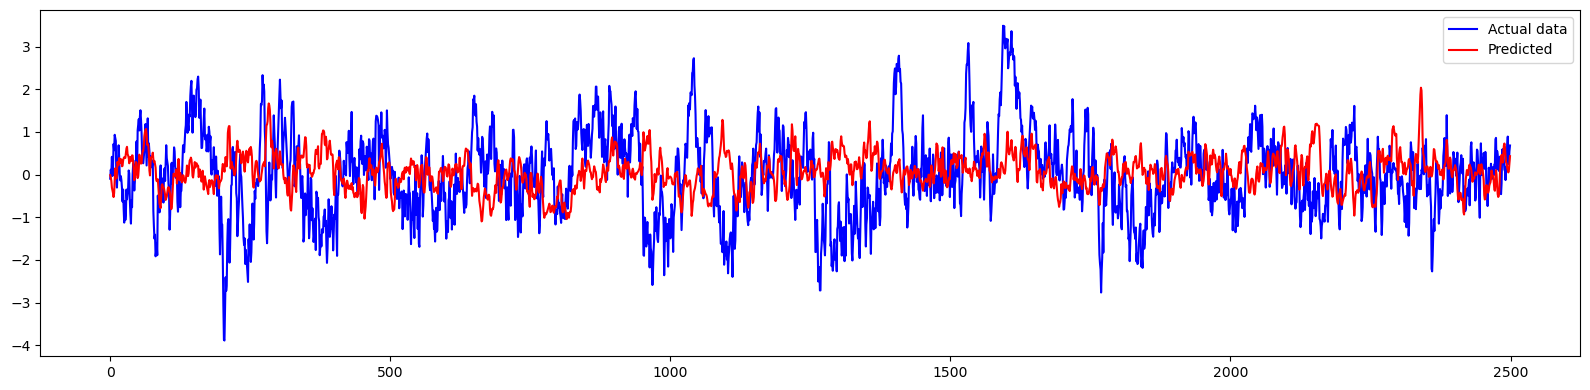

In [71]:
X_gabor    = np.load(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\data\session_1044594870\session_1044594870_spikes_gabor.npy').astype(np.float32)
gabor      = np.load(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\data\session_1044594870\session_1044594870_gabor_lfp.npy').astype(np.float32)
X_gaborT   = torch.tensor( X_gabor ).float()
gabor_lfpT = torch.tensor( gabor ).float()

N = gabor_lfpT.shape[0]
model.eval()
# initialize predicted values
yHat = np.zeros(N)
yHat[:] = np.nan
# yHat = torch.from_numpy(yHat)
# yHat = yHat.to(device)

# loop over time segments
for timei in range(0, N - seqlength, seqlength):

  # grab a snippet of data
  X = X_gaborT[timei:timei+seqlength,:].view(seqlength,1,input_size)
  X = X.to(device)
  # X = lfpT[timei:timei+seqlength].view(seqlength,1,input_size)
  
  # forward pass and loss
  yy = model(X)
  yHat[timei:timei+seqlength] = np.squeeze(yy.cpu().detach().numpy()) # [timei:timei+seqlength]
  # h[timei+seqlength,:] = hh[0].detach()

## plot!
fig,ax = plt.subplots(1,1,figsize=(16,4))
ax.plot(gabor[:int(10/bin_size)],'b',label='Actual data')
# ax.plot(power_test[:int(10/bin_size),4],'b',label='Actual data')
ax.plot(yHat[:int(10/bin_size)],'r',label='Predicted')
ax.legend()

plt.tight_layout()
plt.show()

## attribution analysis using captum

In [29]:
model.train()
X_testT = X_testT.to(device)

# Initialize the attribution algorithm with the model
integrated_gradients = IntegratedGradients(model)
attributions = []
for i in tqdm(range(0,X_testT.shape[0],300)):
  attributions.append(integrated_gradients.attribute(X_testT[i:i+300,:].contiguous(),  target=0,  n_steps=200))

100%|████████████████████████████████████████████████████████████████████████████████| 601/601 [18:31<00:00,  1.85s/it]


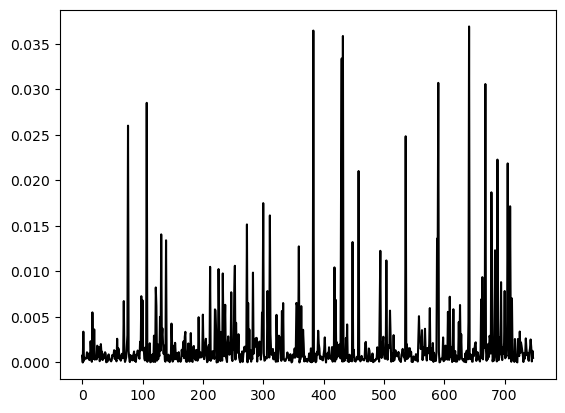

In [44]:
attributions = torch.cat(attributions)
attributions = attributions.cpu().detach().numpy()
mean_attr_over_time = np.mean(attributions,0)
df['attribution'] = mean_attr_over_time

plt.plot(np.arange(0,X_testT.shape[1],1), np.abs(mean_attr_over_time) , 'k')
plt.show()

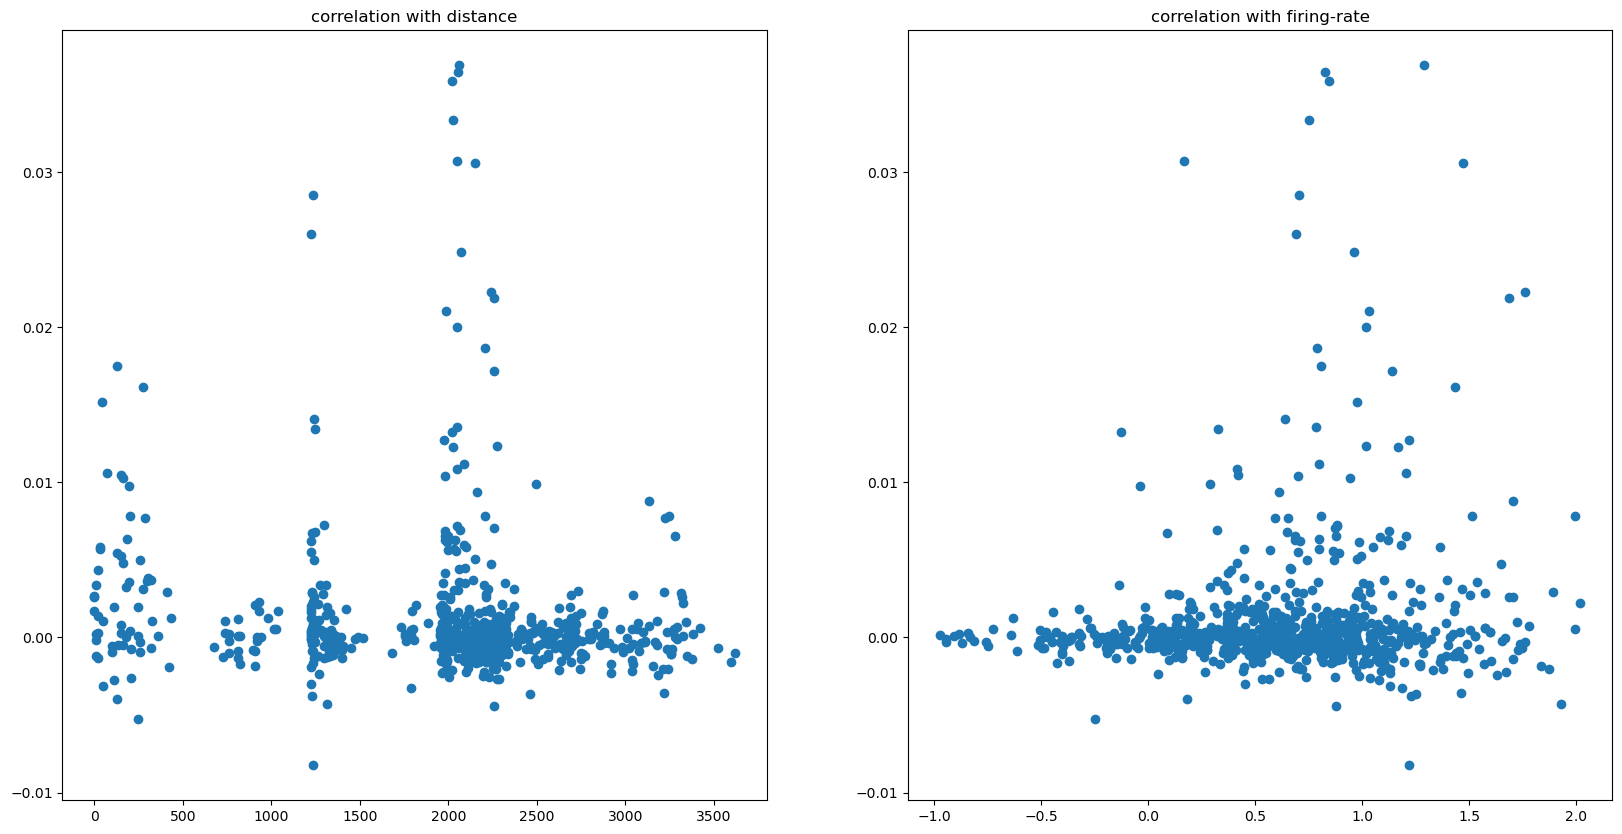

In [40]:
fig, ax = plt.subplots(1,2, figsize=(20,10))

ax[0].scatter(df.dist_from_source, mean_attr_over_time)
ax[0].set_title('correlation with distance')

ax[1].scatter(np.log10(df.firing_rate), mean_attr_over_time)
ax[1].set_title('correlation with firing-rate')
plt.show()

In [45]:
df.head()

,location,probe,firing_rate,dist_from_source,attribution
0,POL,probeB,12.605778,2436.860891,-7.440950e-04
1,CA1,probeB,3.409879,1303.491849,2.420166e-07
2,VISpm,probeB,0.731049,1272.456679,3.385959e-03
3,DG,probeB,0.228691,1770.981931,1.863473e-04
4,POL,probeB,1.995846,2512.222323,5.265902e-04


In [47]:
df[['location', 'attribution', 'firing_rate', 'dist_from_source']].groupby('location').mean().sort_values('attribution',ascending=False)

,attribution,firing_rate,dist_from_source
location,,,
VISal,0.004804,6.426208,2081.784036
VISl,0.003292,4.774797,1991.944407
MGm,0.003088,19.001668,2966.190374
VISrl,0.003002,10.296141,2237.059371
VISp,0.002823,6.818366,164.659059
VISpm,0.002113,4.947556,1242.218513
PP,0.001923,68.461265,3331.802449
PIL,0.001105,42.893935,3112.033759
MGv,0.000406,10.434417,2825.663030


location                  VISal
probe                    probeE
firing_rate           19.355614
dist_from_source    2063.456566
attribution            0.036904
Name: 641, dtype: object


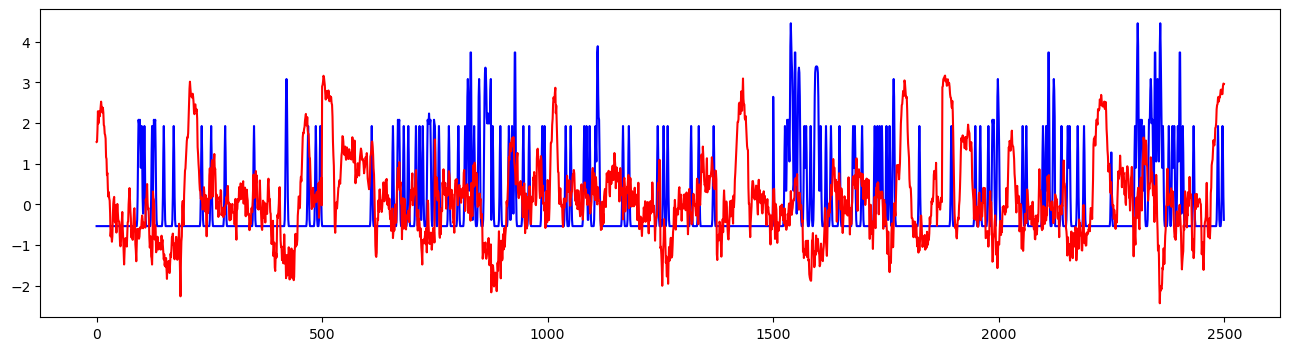

In [64]:
# find the neuron with the highest attribution 
sidx = np.argsort(mean_attr_over_time)[::-1]
print(df.iloc[sidx[0]])
fig,ax = plt.subplots(1,1,figsize=(16,4))
ax.plot(X_test[:int(10/bin_size),sidx[0]],'b',label='best predictor neuron')
ax.plot(y_test[:int(10/bin_size)],'r',label='LFP')
# ax.legend()